In [ ]:
import subprocess
import sys
from importlib_metadata import version as pkg_version, PackageNotFoundError

packages = ["torch", "torchvision", "torchaudio", "matplotlib", "scikit-learn", "kagglehub"]

print("####################################################################")
print("Checking packages and upgrading only if needed (local check)...")
print("-----------------------------------")

for pkg in packages:
    try:
        installed_version = pkg_version(pkg)
        print(f"{pkg} is installed (version {installed_version}). Checking for upgrade...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", pkg])
    except PackageNotFoundError:
        print(f"{pkg} is not installed. Installing now...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("####################################################################")

####################################################################
Checking packages and upgrading only if needed (local check)...
-----------------------------------
opencv-python is not installed. Installing now...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 5.1 MB/s  0:00:09m0:00:0100:01
torch is installed (version 2.10.0). Checking for upgrade...
torchvision is installed (version 0.25.0). Checking for upgrade...
torchaudio is installed (version 2.10.0). Checking for upgrade...
tqdm is installed (version 4.67.3). Checking for upgrade...
matplotlib is installed (version 3.10.8). Checking for upgrade...
scikit-learn is installed (version 1.8.0). Checking for upgrade...
seaborn is installed (version 0.13.2). Checking for upgrade...
kagglehub is installed (version 1.0.0). Checking for upgrade...
ipywidgets is installed (version 8.1.8). Checking for upgrade...
####################################################################


In [ ]:
# Handle imports
import os
import torch
from sklearn.preprocessing import LabelEncoder
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import numpy as np
import kagglehub
import utils
import numpy as np
from sklearn.metrics import classification_report

In [3]:
env = input("Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): ").strip().lower()

model_name = "resnet"
prev_stage = None

path_final_models, path_hackathon_checkpoints, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=False, env=env)

Running in local environment.
The path are:
Final Models: Final_Models/resnet_no_aug
Hackathon Checkpoints: hackathon_checkpoints/resnet_no_aug
Plots: plots/resnet_no_aug
OCT Models: oct_models/resnet_no_aug


In [4]:
# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("####################################################################")
print("Using device:", device)
print("####################################################################")

####################################################################
Using device: cpu
####################################################################


In [5]:
# Download dataset if needed
DATA_PATH = kagglehub.dataset_download("mislamshawon/oct2017")
print("####################################################################################")
print("The path for the dataset is:", DATA_PATH)
print("####################################################################")

# Check folder exists
if os.path.exists(DATA_PATH):
    print("Data folder contents:", os.listdir(os.path.join(DATA_PATH)))
    print("####################################################################")
    print("Train folder contents:", os.listdir(os.path.join(DATA_PATH, "train")))
    print("####################################################################")
    print("Val folder contents:", os.listdir(os.path.join(DATA_PATH, "val")))
    print("####################################################################")
    print("Test folder contents:", os.listdir(os.path.join(DATA_PATH, "test")))
    print("####################################################################")
else:
    print("Path does not exist!")

# Set random seed = 42
rand_seed = 42
np.random.seed(rand_seed)
torch.manual_seed(rand_seed)
torch.cuda.manual_seed_all(rand_seed)

####################################################################################
The path for the dataset is: /Users/georgedikaios/.cache/kagglehub/datasets/mislamshawon/oct2017/versions/1
####################################################################
Data folder contents: ['test', 'train', 'val']
####################################################################
Train folder contents: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
####################################################################
Val folder contents: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
####################################################################
Test folder contents: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
####################################################################


In [8]:
# Create separate DataFrames
train_df = utils.create_dataframe("train", DATA_PATH)
val_df   = utils.create_dataframe("val", DATA_PATH)
test_df  = utils.create_dataframe("test", DATA_PATH)

sum_total_data = len(train_df)+len(val_df)+len(test_df)
print("####################################################################")
print("The total images in the dataset are:", (sum_total_data), "images")
print("####################################################################")

print("####################################################################")
print("The size of the imported data in each folder is:")
print("A) Train size:", len(train_df),"images [",len(train_df)/(sum_total_data) *100,"% ]")
print("B) Validation size:", len(val_df),"images [",len(val_df)/(sum_total_data) *100,"% ]")
print("C) Test size:", len(test_df),"images [",len(test_df)/(sum_total_data) *100,"% ]")
print("####################################################################")

####################################################################
The total images in the dataset are: 84130 images
####################################################################
####################################################################
The size of the imported data in each folder is:
A) Train size: 50580 images [ 60.12124093664567 % ]
B) Validation size: 16851 images [ 20.029715915844527 % ]
C) Test size: 16699 images [ 19.849043147509807 % ]
####################################################################


In [9]:
# Encode Labels to Numbers
le = LabelEncoder()

train_df["label_encoded"] = le.fit_transform(train_df["label"])
val_df["label_encoded"] = le.transform(val_df["label"])
test_df["label_encoded"] = le.transform(test_df["label"])
print("####################################################################")
print("The names of the classes in OCT classification are:")
print("Classes:", le.classes_)
print("Classes have been labeled as 0, 1, 2, 3.")
print("####################################################################")

####################################################################
The names of the classes in OCT classification are:
Classes: ['CNV' 'DME' 'DRUSEN' 'NORMAL']
Classes have been labeled as 0, 1, 2, 3.
####################################################################


In [ ]:
# Image transformation
transform_no_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# Pass Transform Into Dataset
test_dataset = utils.OCTDataset(test_df, transform=transform_no_aug)

In [ ]:
# Create DataLoaders
print("####################################################################")
while True:
    BATCH_SIZE = int(input("Enter batch size (e.g., 32, 64, 128): "))
    if BATCH_SIZE % 8 != 0 and BATCH_SIZE != 1:
        print("Please enter a batch size that is a multiple of 8")
    else:
        break
print("Using batch size:", BATCH_SIZE)
print("####################################################################")

test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

####################################################################
Using batch size: 32
####################################################################



                                        Testing Final Model: ResNet18 with Augmentation


Testing: 100%|██████████| 522/522 [07:26<00:00,  1.17batch/s]



--- Metrics ---
Accuracy: 0.9637 | Precision: 0.9442 | Recall: 0.9539 | F1 Score: 0.9489
Plot saved to plots/resnet_aug/resnet18_cm_roc_aug.png


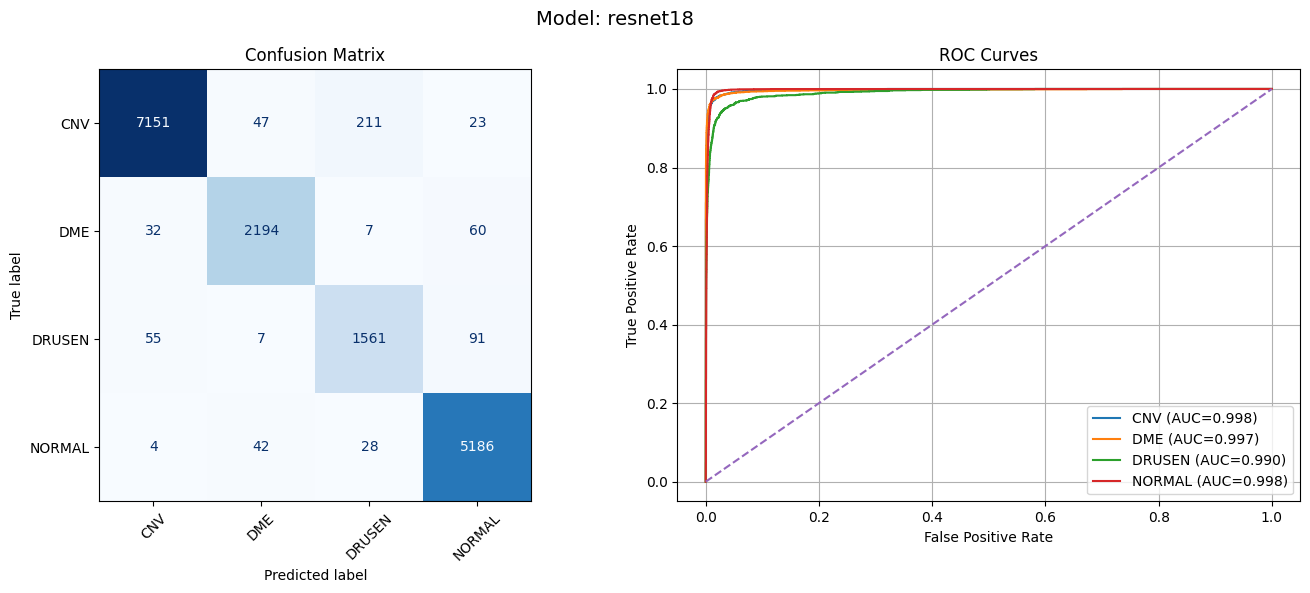

Raw predictions saved for comparison at: plots/resnet_aug/resnet18_results.pth


In [ ]:
# Test ResNet18 with Augmentation
results_dict = {}

print("\n" + "="*130)
print(f"{' '*40}Testing Final Model: ResNet18 with Augmentation")
print("="*130)

model = utils.build_model(model_name='resnet18').to(device)
model.load_state_dict(torch.load(f"{path_final_models}/resnet_augmented_final.pth", map_location=device))

gold, preds, probs = utils.test_model(
    model=model,
    test_dataloader=test_loader,
    device=device,
    class_names=["CNV","DME","DRUSEN","NORMAL"],
    results_dict=results_dict,
    model_name='ResNet18',
    augmented=True,
    path_plots=path_plots
)

In [ ]:
print(classification_report(gold, preds, target_names=["CNV","DME","DRUSEN","NORMAL"]))

In [ ]:
# Test ResNet18 without Augmentation
results_dict = {}
utils.create_paths(model_name=model_name, augmented=False, env=env)

print("\n" + "="*130)
print(f"{' '*40}Testing Final Model: ResNet18 without Augmentation")
print("="*130)

model = utils.build_model(model_name='resnet18').to(device)

model.load_state_dict(torch.load(f"{path_final_models}/resnet_base_final.pth", map_location=device)) 

gold, preds, probs = utils.test_model(
    model=model,
    test_dataloader=test_loader,
    device=device,
    class_names=["CNV","DME","DRUSEN","NORMAL"],
    results_dict=results_dict,
    model_name='resnet18',
    augmented=False,
    path_plots=path_plots
)

In [ ]:
print(classification_report(gold, preds, target_names=["CNV","DME","DRUSEN","NORMAL"]))

In [ ]:
print("####################################################################################")
print("Hello!!! Thank you for using OCT Classification.")
env = input("Please tell me if you are running code on Kaggle, colab or Local? (kaggle/colab/local): ").strip().lower()

model_name = "densenet"
prev_stage = None

path_final_models, path_hackathon_checkpoints, path_plots, path_oct_models = utils.create_paths(model_name=model_name, augmented=False, env=env)

In [ ]:
# Test DenseNet121 without Augmentation
results_dict = {}

print("\n" + "="*130)
print(f"{' '*40}Testing Final Model: DenseNet121 without Augmentation")
print("="*130)

model = utils.build_model(model_name='densenet121').to(device)

model.load_state_dict(torch.load(f"{path_final_models}/densenet_base_final.pth", map_location=device))

gold, preds, probs = utils.test_model(
    model=model,
    test_dataloader=test_loader,
    device=device,
    class_names=["CNV","DME","DRUSEN","NORMAL"],
    results_dict=results_dict,
    model_name='DenseNet121',
    augmented=False,
    path_plots=path_plots
)

In [ ]:
print(classification_report(gold, preds, target_names=["CNV","DME","DRUSEN","NORMAL"]))